In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df_2011 = pd.read_csv('master2011_sale.csv')
df_2021 = pd.read_csv('master2021_sale.csv')

In [4]:
print(df_2011.columns)
print(df_2021.columns)

Index(['LSOA code', 'ward', 'ward code', 'local authority name',
       'local authority code', 'fullAddress', 'Postcode', 'bathrooms',
       'bedrooms', 'floorAreaSqM', 'livingRooms', 'tenure', 'propertyType',
       'currentEnergyRating', 'Time2', 'saleEstimate_Time2',
       'saleEstimate_confidenceLevel', 'saleEstimate_T1T2Change.percentage',
       'Time1', 'saleEstimate_Time1', 'history_date', 'history_price',
       'Postcode district', 'Latitude', 'Longitude', 'Rural/urban', 'Altitude',
       'London zone', 'Nearest station', 'Distance to station', 'Police force',
       'Average Income', 'Travel To Work Area', 'IMD decile',
       '2011_accommodation type_most_common_type',
       '2011_accommodation type_most_common_prop',
       '2011_Age on arrival in UK_most_common_type',
       '2011_Age on arrival in UK_most_common_prop',
       '2011_cars or vans_most_common_type',
       '2011_cars or vans_most_common_prop',
       '2011_central heating_most_common_type',
       '201

In [5]:
# 예측에 불필요한 컬럼(주소, 코드, 위경도 등) 제거
drop_cols = [
    'LSOA code', 'ward', 'ward code', 'local authority name', 'local authority code',
    'fullAddress', 'Postcode', 'Time2', 'Time1', 'history_date', 'Postcode district',
    'Latitude', 'Longitude', 'Nearest station', 'Police force', 'Travel To Work Area'
]

In [6]:
# 예측에 사용할 타겟 변수와 피처(특징) 선택
# 'saleEstimate_Time2' 를 타겟변수로 잡아야하나..?
target_col = 'history_price'

In [7]:
X_2011 = df_2011.drop(drop_cols + [target_col], axis=1)
y_2011 = df_2011[target_col]
X_2011 = X_2011.dropna()
y_2011 = y_2011.loc[X_2011.index]
X_2011 = pd.get_dummies(X_2011, drop_first=True)

X_2021 = df_2021.drop(drop_cols + [target_col], axis=1)
y_2021 = df_2021[target_col]
X_2021 = X_2021.dropna()
y_2021 = y_2021.loc[X_2021.index]
X_2021 = pd.get_dummies(X_2021, drop_first=True)

X_2011, X_2021 = X_2011.align(X_2021, join='outer', axis=1, fill_value=0)

In [8]:
# 스케일링
scaler = StandardScaler()
X_2011_scaled = scaler.fit_transform(X_2011)
X_2021_scaled = scaler.fit_transform(X_2021)


In [9]:
# 학습/테스트 분할
X_train_2011, X_test_2011, y_train_2011, y_test_2011 = train_test_split(X_2011_scaled, y_2011, test_size=0.2, random_state=42)
X_train_2021, X_test_2021, y_train_2021, y_test_2021 = train_test_split(X_2021_scaled, y_2021, test_size=0.2, random_state=42)


In [10]:
gbm_2011 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm_2021 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm_2011.fit(X_train_2011, y_train_2011)
gbm_2021.fit(X_train_2021, y_train_2021)

GradientBoostingRegressor(random_state=42)

In [11]:
y_pred_2011 = gbm_2011.predict(X_test_2011)
y_pred_2021 = gbm_2021.predict(X_test_2021)
mse_2011 = mean_squared_error(y_test_2011, y_pred_2011)
r2_2011 = r2_score(y_test_2011, y_pred_2011)
mse_2021 = mean_squared_error(y_test_2021, y_pred_2021)
r2_2021 = r2_score(y_test_2021, y_pred_2021)

print(f"2011 테스트 MSE: {mse_2011:.2f}")
print(f"2011 테스트 R^2: {r2_2011:.3f}")
print(f"2021 테스트 MSE: {mse_2021:.2f}")
print(f"2021 테스트 R^2: {r2_2021:.3f}")

2011 테스트 MSE: 452263983025.19
2011 테스트 R^2: 0.708
2021 테스트 MSE: 465582207367.79
2021 테스트 R^2: 0.699


C:\Users\USER\AppData\Local\Temp\ipykernel_29276\2293690069.py:22: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_29276\2293690069.py:22: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_29276\2293690069.py:22: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_29276\2293690069.py:22: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_29276\2293690069.py:22: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_29276\2293690069.py:22: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  plt.tight_layout()
C:\Us

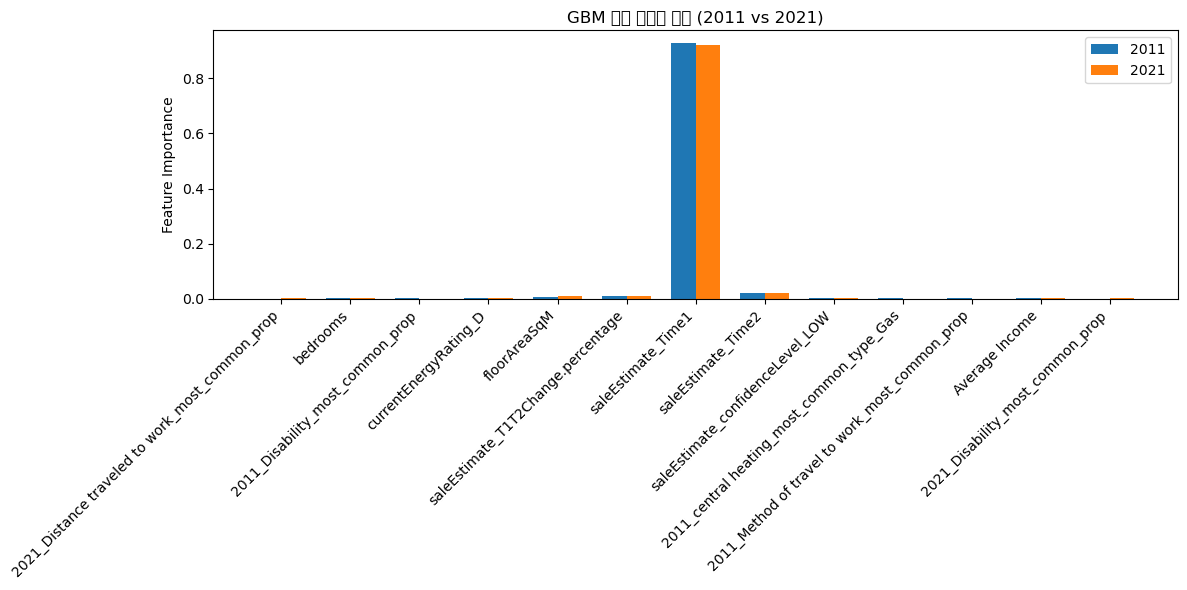

In [12]:
# 변수 중요도 비교 (상위 10개)
import matplotlib.pyplot as plt
import numpy as np

feature_names = X_2011.columns
importance_2011 = gbm_2011.feature_importances_
importance_2021 = gbm_2021.feature_importances_

top_indices_2011 = np.argsort(importance_2011)[::-1][:10]
top_indices_2021 = np.argsort(importance_2021)[::-1][:10]
top_indices = list(set(top_indices_2011) | set(top_indices_2021))

plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(top_indices))
plt.bar(x - bar_width/2, importance_2011[top_indices], bar_width, label='2011')
plt.bar(x + bar_width/2, importance_2021[top_indices], bar_width, label='2021')
plt.xticks(x, feature_names[top_indices], rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('GBM 변수 중요도 비교 (2011 vs 2021)')
plt.legend()
plt.tight_layout()
plt.show()